# 06 — ONNX Export

Phase 6: export the trained forward surrogate to ONNX so Phase 7's forward playground can run
entirely client-side via `onnxruntime-web` — no backend, static page. The INVERSE optimization
cannot make this trip: onnxruntime-web doesn't do backpropagation, so Phase 7's "solve for
physics" button calls a small Python backend that imports `graydiff` directly and runs the
exact same PyTorch code these notebooks have already validated. Only the forward rollout needs
an exported artifact.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

from graydiff.export import export_to_onnx, verify_onnx_parity
from graydiff.model import Surrogate, make_input
from graydiff.solver import standard_seed
from graydiff.constants import SPOTS_CHECKPOINT, MAZES_CHECKPOINT, F_RANGE, K_RANGE

plt.rcParams["figure.facecolor"] = "white"

GRID = 64
model = Surrogate(hidden=64)
model.load_state_dict(torch.load("../models/checkpoints/surrogate_rollout.pt", map_location="cpu"))
model.eval()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 77,378


## Export

Always from a CPU-resident copy (`graydiff.export.export_to_onnx` handles this internally),
regardless of what device the checkpoint was trained on.

In [2]:
onnx_path = export_to_onnx(model, "../models/onnx/surrogate.onnx", grid_size=GRID)
size_kb = os.path.getsize(onnx_path) / 1e3
print(f"Exported to {onnx_path} ({size_kb:.1f} KB, single file)")

W0713 08:59:46.505000 60767 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


W0713 08:59:46.506000 60767 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align


W0713 08:59:46.506000 60767 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool


W0713 08:59:46.506000 60767 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::deform_conv2d


[torch.onnx] Obtain model graph for `Surrogate([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `Surrogate([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


Exported to ../models/onnx/surrogate.onnx (343.8 KB, single file)


/opt/homebrew/Cellar/python@3.11/3.11.15_3/Frameworks/Python.framework/Versions/3.11/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


## Verify numeric parity

The whole point of exporting is that the browser's copy of the model behaves identically to
the one every earlier notebook validated. Confirm it, on random inputs first, then on a real
autoregressive rollout — the actual usage pattern the forward playground will exercise, not
just a single forward pass.

In [3]:
max_diff = verify_onnx_parity(model, onnx_path, grid_size=GRID, n_trials=10)
print(f"Max |torch - onnx| over 10 random inputs: {max_diff:.2e}")

Max |torch - onnx| over 10 random inputs: 4.77e-07


Max |torch - onnx| after a 100-step AUTOREGRESSIVE rollout: 5.96e-07


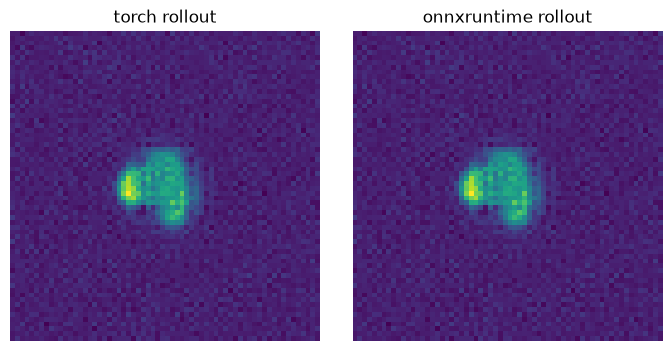

In [4]:
import onnxruntime as ort

session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])

def onnx_rollout(F, k, n_steps):
    U, V = standard_seed(GRID, GRID)
    state = np.stack([U, V]).astype(np.float32)[None]
    F_grid = np.full((1, 1, GRID, GRID), F, dtype=np.float32)
    k_grid = np.full((1, 1, GRID, GRID), k, dtype=np.float32)
    for _ in range(n_steps):
        x = np.concatenate([state, F_grid, k_grid], axis=1)
        state = session.run(None, {"input": x})[0]
    return state

def torch_rollout(F, k, n_steps):
    U, V = standard_seed(GRID, GRID)
    state = torch.from_numpy(np.stack([U, V])).float().unsqueeze(0)
    F_t, k_t = torch.tensor([F]), torch.tensor([k])
    with torch.no_grad():
        for _ in range(n_steps):
            state = model(make_input(state, F_t, k_t))
    return state.numpy()

N_CHECK_STEPS = 100
onnx_final = onnx_rollout(SPOTS_CHECKPOINT["F"], SPOTS_CHECKPOINT["k"], N_CHECK_STEPS)
torch_final = torch_rollout(SPOTS_CHECKPOINT["F"], SPOTS_CHECKPOINT["k"], N_CHECK_STEPS)
rollout_diff = np.abs(onnx_final - torch_final).max()
print(f"Max |torch - onnx| after a {N_CHECK_STEPS}-step AUTOREGRESSIVE rollout: {rollout_diff:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(torch_final[0, 1], cmap="viridis"); axes[0].set_title("torch rollout")
axes[1].imshow(onnx_final[0, 1], cmap="viridis"); axes[1].set_title("onnxruntime rollout")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("../figures/06_onnx_parity.png", dpi=110, bbox_inches="tight")
plt.show()

## Artifacts for the web frontend

Copy the phase-diagram cache (notebook 00) and a small set of pre-solved presets (so a passive
visitor sees results without drawing) into `web/frontend/data/`, alongside the ONNX model.

In [5]:
import shutil

os.makedirs("../web/frontend/data", exist_ok=True)
shutil.copy("../data/phase_diagram_cache/phase_diagram.json", "../web/frontend/data/phase_diagram.json")
shutil.copy(onnx_path, "../web/frontend/data/surrogate.onnx")
print("Copied phase_diagram.json and surrogate.onnx into web/frontend/data/")

Copied phase_diagram.json and surrogate.onnx into web/frontend/data/


In [6]:
presets = [
    {"name": "Spots", "F": SPOTS_CHECKPOINT["F"], "k": SPOTS_CHECKPOINT["k"]},
    {"name": "Mazes", "F": MAZES_CHECKPOINT["F"], "k": MAZES_CHECKPOINT["k"]},
    {"name": "Near-boundary (dead/uniform)", "F": 0.065, "k": 0.06},
]
for p in presets:
    U, V = standard_seed(GRID, GRID)
    state = torch.from_numpy(np.stack([U, V])).float().unsqueeze(0)
    F_t, k_t = torch.tensor([p["F"]]), torch.tensor([p["k"]])
    with torch.no_grad():
        for _ in range(150):
            state = model(make_input(state, F_t, k_t))
    p["preview_V"] = state[0, 1].clamp(0, 1).tolist()

with open("../web/frontend/data/presets.json", "w") as f:
    json.dump({"grid_size": GRID, "F_range": list(F_RANGE), "k_range": list(K_RANGE), "presets": presets}, f)
print(f"Wrote web/frontend/data/presets.json with {len(presets)} presets")
print("Files in web/frontend/data/:", sorted(os.listdir("../web/frontend/data")))

Wrote web/frontend/data/presets.json with 3 presets
Files in web/frontend/data/: ['phase_diagram.json', 'presets.json', 'surrogate.onnx']


## Summary

- Exported the trained surrogate to a single-file ONNX model (`models/onnx/surrogate.onnx`,
  committed to the repo — small enough to track directly, and it's the actual deployment
  artifact).
- Verified numeric parity against the torch model both on random single-step inputs and on a
  real autoregressive rollout — the usage pattern the forward playground actually exercises.
- Staged everything Phase 7's static frontend needs — the ONNX model, the phase-diagram cache,
  and a few precomputed presets — in `web/frontend/data/`.

**Next:** Phase 7 wires up the interactive UI: a draw-a-target canvas, the in-browser forward
playground (via `onnxruntime-web`, using exactly this exported model), a phase-diagram view
with the optimizer's search trajectory, and a small FastAPI backend for the inverse solve
(which needs backprop, so it stays server-side and imports `graydiff` directly).